# Home assignment 2 (__100__ virtual points)

### IMPORTANT!

1. This notebook (`.ipynb` file) is what you hand in. It must contain both your code and the results of its execution. Notebooks without execution results will receive penalties.
   1. The notebook must be named as follows: `SurnameHW2.ipynb`.
   2. Please do _not_ hand in `.py` files.
3. One should be able to press the "Restart and run all" `>>` button and get the same results as you did. Use NumPy's [fixed random seeds](https://numpy.org/doc/stable/reference/random/generator.html) and sklearn's `random_state`s for reproducibility.
4. If your answer is a piece of text, it should be put in a Markdown cell.
5. Code with comments is appreciated.

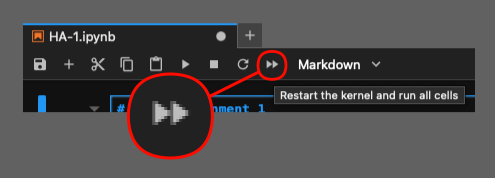

### Notes

These tasks require you to use new Python libraries: Optuna and potentially `joblib`. Please be not afraid, they're easy to use and are generally very handy in day-to-day work.

- Optuna documentation: https://optuna.readthedocs.io/en/stable/index.html.
- Joblib documentation: https://joblib.readthedocs.io/en/stable/.

"Virtual points" means that one point here does _not_ necessarily equal one point in РПД. We are going to grade this assignment out of 100 points, then scale the grades accordingly afterwards.

In [1]:
import numpy as np, matplotlib.pyplot as plt, polars as pl
from scipy import stats

import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
from joblib import Parallel, delayed

# 1. Handwritten digit recognition with SVM (20 points)

Train a Support Vector Machine to tell what digit is written in an image.

__NOTE:__ Each observation has 700+ features. Use __dimensionality reduction__ before fitting the SVM.

In [3]:
df = pl.read_parquet("https://github.com/Michael-tehc/MachineLearning-MSU/raw/refs/heads/main/data/mnist_train.parquet")
df

label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,1x11,1x12,1x13,1x14,1x15,1x16,1x17,1x18,1x19,1x20,1x21,1x22,1x23,1x24,1x25,1x26,1x27,1x28,2x1,2x2,2x3,2x4,2x5,2x6,2x7,2x8,…,27x20,27x21,27x22,27x23,27x24,27x25,27x26,27x27,27x28,28x1,28x2,28x3,28x4,28x5,28x6,28x7,28x8,28x9,28x10,28x11,28x12,28x13,28x14,28x15,28x16,28x17,28x18,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,…,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
X, y = df[:, 1:].to_numpy(), df['label'].to_numpy()
X.shape, y.shape

((60000, 784), (60000,))

## 1.1. Hyperparameter search (10 points)

Use a validation dataset to find the "best" hyperparameters for the SVM.

- "Best" means "resulting in highest _accuracy_".
- Make an educated guess as to which hyperparameters may affect the model's performance the most.
- Do not try too many hyperparameter combinations.

In [5]:
Xtrain, Xval, ytrain, yval = ...

In [6]:
df_test = pl.read_parquet("https://github.com/Michael-tehc/MachineLearning-MSU/raw/refs/heads/main/data/mnist_test.parquet")
Xtest, ytest = ...
Xtest.shape, ytest.shape

((10000, 784), (10000,))

Write code for hyperparameter tuning manually. Use [joblib](https://joblib.readthedocs.io/en/stable/) to utilize all CPU cores and speed up processing.

In [7]:
def find_ncomponents(possible_components: range, Xtrain, Xval, ytrain, yval):
    accuracies = ... # one accuracy per number of principal components
    return pl.DataFrame({
        'C': list(possible_components),
        'acc': accuracies
    })

In [8]:
df_val = find_ncomponents(range(2, 20, 2), Xtrain, Xval, ytrain, yval)
df_val

C,acc
i64,f64
2,0.275944
4,0.476611
6,0.815
8,0.888056
10,0.914167
12,0.928167
14,0.939056
16,0.943833
18,0.949111


## 1.2. Evaluate the model's performance on the test dataset (10 points)

Use data from `data/mnist_test.parquet`.

1. Train the model with the best hyperparameters on hte full training dataset.
2. Plot the confusion matrix for the test dataset.

In [9]:
best_model = ...

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pca', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",18
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver 

In [10]:
yhat = ...

In [11]:
(yhat == yval).mean()

np.float64(0.9491111111111111)

In [1]:
# confusion matrix here

1. What do these numbers mean? Interpret the number in row 3, column 4.
2. Which digits confuse the model the most? Why?

# 2. Decision tree regression (40 points)

Predict log-prices and check if residuals are Gaussian.

In [13]:
df2 = pl.read_csv('https://raw.githubusercontent.com/Michael-tehc/MachineLearning-MSU/refs/heads/main/data/Housing.csv').with_columns(
    pl.col('price','area').log()
)
df2

price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
f64,f64,i64,i64,i64,str,str,str,str,str,i64,str,str
16.403275,8.911934,4,2,3,"""yes""","""no""","""no""","""no""","""yes""",2,"""yes""","""furnished"""
16.321036,9.100526,4,4,4,"""yes""","""no""","""no""","""no""","""yes""",3,"""no""","""furnished"""
16.321036,9.206332,3,2,2,"""yes""","""no""","""yes""","""no""","""no""",2,"""yes""","""semi-furnished"""
16.318175,8.922658,4,2,2,"""yes""","""no""","""yes""","""no""","""yes""",3,"""yes""","""furnished"""
16.250001,8.911934,4,1,2,"""yes""","""yes""","""yes""","""no""","""yes""",2,"""no""","""furnished"""
…,…,…,…,…,…,…,…,…,…,…,…,…
14.414347,8.006368,2,1,1,"""yes""","""no""","""yes""","""no""","""no""",2,"""no""","""unfurnished"""
14.384879,7.783224,3,1,1,"""no""","""no""","""no""","""no""","""no""",0,"""no""","""semi-furnished"""
14.375126,8.194229,2,1,1,"""yes""","""no""","""no""","""no""","""no""",0,"""no""","""unfurnished"""


In [14]:
X2, y2 = df2.select('area', 'bedrooms', 'bathrooms', 'stories').to_numpy(), df2['price'].to_numpy()

### 2.1 Collect the entire decision tree construction code from `lec-11.ipynb` into one class (8 points)

Keep impurity functions, answer functions and regularization functions separate.  
Make adjustments to the code so that the following pruning functions would also work.

In [15]:
def max_leaf_nodes(max_nodes):
    """
    Функция, которая создает проверку остановки построения дерева по количеству терминальных вершин
    """
    def check(X, y, depth, leaf_nodes, ig):
        return leaf_nodes >= max_nodes
    return check

def min_impurity_decrease(min_ig):
    """
    Функция, которая создает проверку остановки построения дерева по величине IG
    """
    def check(X, y, depth, leaf_nodes, ig):
        return ig <= min_ig
    return check

def combine_early_stoppings(*stops):
    """
    Функция, которая объединяет различные методы pruning
    """
    def check(X, y, depth, leaf_nodes, ig):
        for stop in stops:
            if stop(X, y, depth, leaf_nodes, ig):
                return True
        return False
    return check

In [16]:
class MyDecisionTree:
    ...

In [17]:
def entropy(y):
    ...

def stop_by_depth(max_depth):
    ...

def classification_answer(y):
    ...

### 2.2 Implement the MSE impurity function. Implement the regression answer function. (5 points)

Which answer function makes sense for a regression problem? Why?

In [18]:
def mse_impurity(y):
    ...

def regression_answer(y):
    ...

### 2.3. Use `optuna` to find the best `DecisionTreeRegressor` to predict house prices (8 points)

Use [Optuna](https://optuna.org) to find the best hyperparameters for `DecisionTreeRegressor` from `sklearn`.

1. Choose what it means to be "the best". Explain why you chose this metric.
2. Learn how to use Optuna: https://optuna.readthedocs.io/en/stable/index.html.
3. Find the best values of `max_depth`, `min_sample_leaf`, `min_impurity_decrease` and possibly other hyperparameters.

In [20]:
def objective_tree(trial: optuna.Trial):
    ...

# minimize `objective_tree`
study = ...
study.best_params

{'max_depth': 10,
 'min_sample_leaf': 3,
 'min_impurity_decrease': 0.00037364372611013914}

In [21]:
tree = ... # fit new tree with best hyperparameters
resid2 = ... # residuals

### 2.4. Do the residuals follow a Gaussian distribution? (7 points)

Implement the Q-Q plot _by hand_ and check whether the model's residuals are Gaussian.

The Q-Q plot must be plotted using `plt.plot(quantiles_theoretical, quantiles_empirical, '.-')`. The actual quantiles must be computed using NumPy, no sklearn or statsmodels. Use [`scipy.stats.norm`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html#scipy.stats.norm) to compute Gaussian quantiles.

In [22]:
def QQ_compute(residuals: np.ndarray, nquantiles: int, eps=1e-3):
    assert nquantiles > 0
    assert eps > 0
    ...
    return q_theoretical, q_empirical, loc, scale

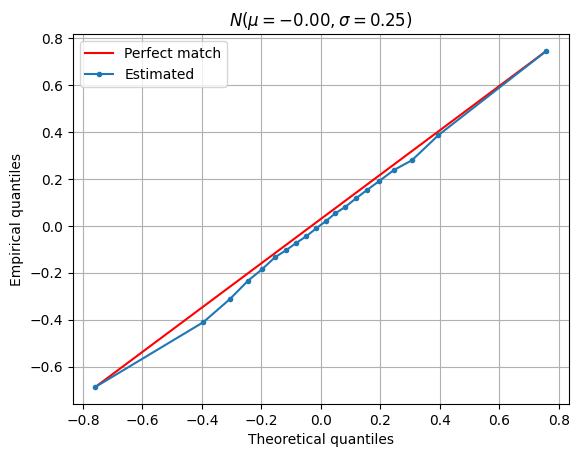

In [23]:
q_theoretical, q_empirical, loc, scale = QQ_compute(resid2, 20)
plt.plot(
    np.linspace(q_theoretical.min(), q_theoretical.max()),
    np.linspace(q_empirical.min(), q_empirical.max()),
    c='red', label='Perfect match'
)
plt.plot(q_theoretical, q_empirical, '.-', label='Estimated')
plt.legend()
plt.title(fr"$N(\mu={loc:.2f}, \sigma={scale:.2f})$")
plt.xlabel('Theoretical quantiles')
plt.ylabel('Empirical quantiles')
plt.grid(); plt.gca();

Do the residuals seem normally distributed? Why? Why not?

### 2.5. Which features are the most important for the tree? (5 points)

Get the _names_ of the top-3 most important features. What does it mean for them to be "most important"?

In [2]:
# your code here

### 2.6 Fit your own implementation of the decision tree to the same data with the same hyperparamethers (7 points)

Do the results differ from those produced by `sklearn`'s' `DecisionTreeRegressor`? What actually differs? Why?

In [3]:
# your code here

# 3. Issues with the EM algorithm for 1D Gaussian mixtures (40 points)

Implement the EM algorithm from scratch and explore its shortcomings when the number of clusters is too high.

## 3.1. Sample from a given Gaussian mixture (15 points)

Fill in the `rand` method and verify that the histogram has two humps at $-1$ and $1$.

In [27]:
from dataclasses import dataclass
@dataclass
class Mixture:
    ps: list # weights
    ms: list # component locations
    ss: list # component scales

    def rand(self, nobs: int, random_state=None) -> np.ndarray:
        assert len(self.ps) == len(self.ms) == len(self.ss)
        K = len(self.ps)
        rng = np.random.RandomState(random_state)
        samples = []
        ...
        assert len(samples) == nobs
        return np.array(samples)

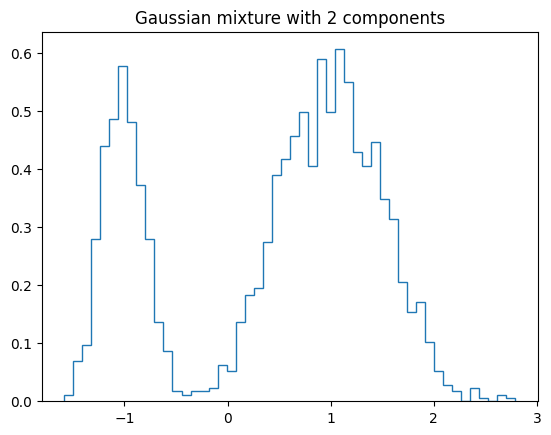

In [28]:
plt.hist(
    Mixture([0.3, 0.7], [-1, 1], [0.2, .5]).rand(2000),
    histtype='step', bins=50, density=True
)
plt.title("Gaussian mixture with 2 components");

## 3.2. Fit mixtures via the EM algorithm (20 points)

Fill in the blanks in `MyGaussianMixture.fit`.

In [29]:
class MyGaussianMixture:
    def __init__(
        self, n_components: int,
        max_iter=1000, # NOTE: keep max_iter high!
        random_state=None
    ):
        self.n_components, self.max_iter = n_components, max_iter
        self.random_state = random_state

    def logpdf(self, xs: np.ndarray):
        def _logpdf(x: float):
            return np.log(
                self.weights_.dot(
                    np.exp(-0.5 * (x - self.locations_)**2 / self.scales_**2) / (
                        np.sqrt(2 * np.pi) * self.scales_
                    )
                )
            )
        return np.vectorize(_logpdf)(xs)

    def pdf(self, xs): return np.exp(self.logpdf(xs))

    def log_likelihood(self, xs: np.ndarray):
        return self.logpdf(xs).sum()

    def risk(self, xs: np.ndarray):
        return -self.log_likelihood(xs) / len(xs)

    def fit(self, xs: np.ndarray):
        N = len(xs)
        # 1. Initialize
        km = KMeans(
            self.n_components, random_state=self.random_state
        ).fit(xs.reshape(-1, 1))
        self.locations_ = ...
        labels = km.labels_.flatten()
        self.weights_ = np.array([
            ...
            for k in range(self.n_components)
        ])
        self.scales_ = np.array([
            xs[labels == k].std() + 1
            for k in range(self.n_components)
        ])
        # 2. Run EM algorithm
        for epoch in range(self.max_iter):
            # 2.1 Matrix of posterior probabilities
            Q = ...
            assert Q.shape == (N, self.n_components)

            # 2.2 Update mixture parameters
            self.weights_[:] = ...
            self.locations_[:] = ...
            self.scales_[:] = ...
            if epoch % 100 == 0:
                print(epoch, self.scales_, self.risk(xs))
        return self

0 [0.94445285 0.87091705 0.79755542] 1.4172570215860245
100 [0.50059107 0.19158284 0.47140302] 1.0871453078366744
200 [0.44201613 0.19279511 0.44144087] 1.0868219095061171
300 [0.44055183 0.19283099 0.44083504] 1.086821587869872
400 [0.44032313 0.19283303 0.44093845] 1.086821547711017
500 [0.44010258 0.19283487 0.44104519] 1.0868215081212786
600 [0.43988338 0.19283671 0.44115136] 1.0868214690832758
700 [0.43966549 0.19283853 0.44125694] 1.0868214305885842
800 [0.43944889 0.19284034 0.44136192] 1.0868213926288763
900 [0.43923357 0.19284215 0.44146632] 1.0868213551959238


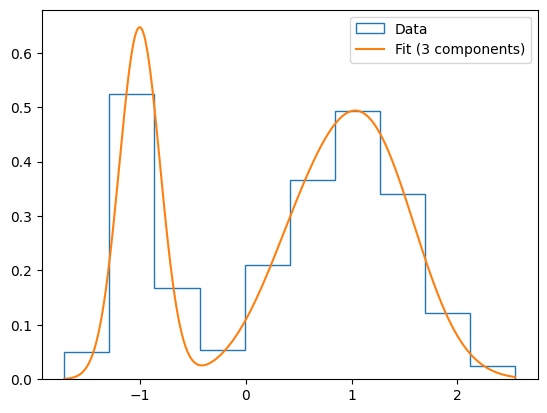

In [30]:
def _plot_fit(n_components: int):
    data = Mixture([0.3, 0.7], [-1, 1], [0.2, .5]).rand(2000)
    gmm = MyGaussianMixture(n_components).fit(data)
    
    xs = np.linspace(data.min(), data.max(), 500)
    fig, ax = plt.subplots()
    ax.hist(data, histtype='step', density=True, label="Data")
    ax.plot(xs, gmm.pdf(xs), label=f'Fit ({n_components} components)')
    ax.legend()
    return fig
_plot_fit(3);

## 3.3. Try to fit a 10-component mixture to the following data (5 points)

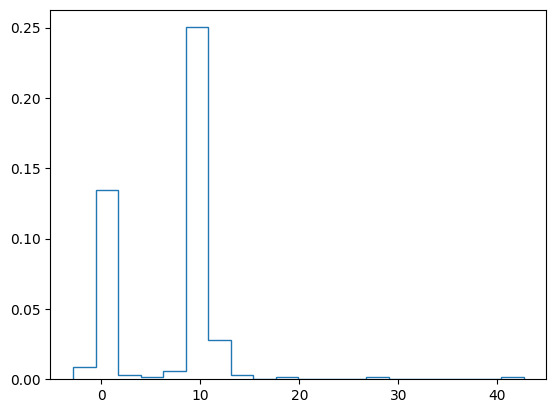

In [31]:
X_mixture = np.concat([
    0.1 * np.random.RandomState(4).standard_cauchy(size=100),
    10 + 0.2 * np.random.RandomState(5).standard_cauchy(size=200)
])
plt.hist(X_mixture, histtype='step', bins=20, density=True);

In [32]:
# code here

0 [6.40983015e-01 6.30045214e-01 8.74595063e-08 1.13457732e-24
 9.52271172e-01 1.18965096e+00 1.83515475e+00 1.85398306e+00
 9.24898377e-02 1.24962444e+00] 1.4199715058207085
100 [nan nan nan nan nan nan nan nan nan nan] nan
200 [nan nan nan nan nan nan nan nan nan nan] nan
300 [nan nan nan nan nan nan nan nan nan nan] nan
400 [nan nan nan nan nan nan nan nan nan nan] nan
500 [nan nan nan nan nan nan nan nan nan nan] nan
600 [nan nan nan nan nan nan nan nan nan nan] nan
700 [nan nan nan nan nan nan nan nan nan nan] nan
800 [nan nan nan nan nan nan nan nan nan nan] nan
900 [nan nan nan nan nan nan nan nan nan nan] nan


/var/folders/d7/wg2mph255p3ck4hg2f7xrkvh0000gn/T/ipykernel_11245/3088014288.py:49: RuntimeWarning: divide by zero encountered in divide
  -0.5 * (xs[:, None] - self.locations_[None, :])**2 / self.scales_[None, :]**2
/var/folders/d7/wg2mph255p3ck4hg2f7xrkvh0000gn/T/ipykernel_11245/3088014288.py:49: RuntimeWarning: invalid value encountered in divide
  -0.5 * (xs[:, None] - self.locations_[None, :])**2 / self.scales_[None, :]**2
/var/folders/d7/wg2mph255p3ck4hg2f7xrkvh0000gn/T/ipykernel_11245/3088014288.py:48: RuntimeWarning: invalid value encountered in divide
  Q = self.weights_[None, :] * np.exp(


1. Does the code fail? Why? Why not? If not, try increasing the number of iterations. If it doesn't error out anyway, there's probably a bug.
2. What feature of the model causes this?
3. What can be done to prevent this?